# Discount Strategy & Customer Engagement Analysis

**Business Question:** Is the company's discounting strategy effectively driving revenue, customer engagement, retention, and conversion — or is it eroding margins without meaningful return?

This notebook visualises findings from the SQL analyses to surface actionable insights for the Head of Marketing, CRM Manager, and Executive Leadership.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Load data
df = pd.read_csv("../data/cleaned/customer_data_clean.csv")

# Reconstruct engineered features (mirrors notebook 02)
binary_map = {"Yes": 1, "No": 0}
df["discount_flag"] = df["discount_applied"].map(binary_map)
df["subscription_flag"] = df["subscription_status"].map(binary_map)

frequency_map = {"Weekly": 5, "Fortnightly": 4, "Monthly": 3, "Quarterly": 2, "Annually": 1}
df["purchase_frequency_score"] = df["frequency_of_purchases"].map(frequency_map)

df["loyalty_score"] = round(np.log(df["previous_purchases"] + 1), 4)

def loyalty_tier(x):
    if x <= 5: return "New"
    elif x <= 15: return "Returning"
    else: return "Loyal"

df["loyalty_tier"] = df["previous_purchases"].apply(loyalty_tier)
df["value_tier"] = pd.qcut(df["purchase_amount_usd"], q=3, labels=["Low", "Medium", "High"])
df["customer_value_score"] = round(df["purchase_amount_usd"] * (1 + df["loyalty_score"]), 2)

def review_sentiment(x):
    if x < 3: return "Low"
    elif x < 4: return "Neutral"
    else: return "High"

df["review_sentiment"] = df["review_rating"].apply(review_sentiment)
df["high_value_low_satisfaction_flag"] = np.where(
    (df["value_tier"] == "High") & (df["review_sentiment"] == "Low"), 1, 0
)

print(f"Dataset loaded: {df.shape[0]:,} customers, {df.shape[1]} features")
df.head(3)

Dataset loaded: 3,900 customers, 24 features


,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,season,review_rating,subscription_status,...,frequency_of_purchases,discount_flag,subscription_flag,purchase_frequency_score,loyalty_score,loyalty_tier,value_tier,customer_value_score,review_sentiment,high_value_low_satisfaction_flag
0,1,55,Male,Blouse,Clothing,53,Kentucky,Winter,3.1,Yes,...,Fortnightly,1,1,4,2.7081,Returning,Medium,196.53,Neutral,0
1,2,19,Male,Sweater,Clothing,64,Maine,Winter,3.1,Yes,...,Fortnightly,1,1,4,1.0986,New,Medium,134.31,Neutral,0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,Spring,3.1,Yes,...,Weekly,1,1,5,3.1781,Loyal,Medium,305.00,Neutral,0


---
## 1. Discount Usage Rate Across Loyalty Tiers

**Question:** Are loyal customers receiving discounts at the same rate as new customers? If so, the business is subsidising customers who would purchase anyway.

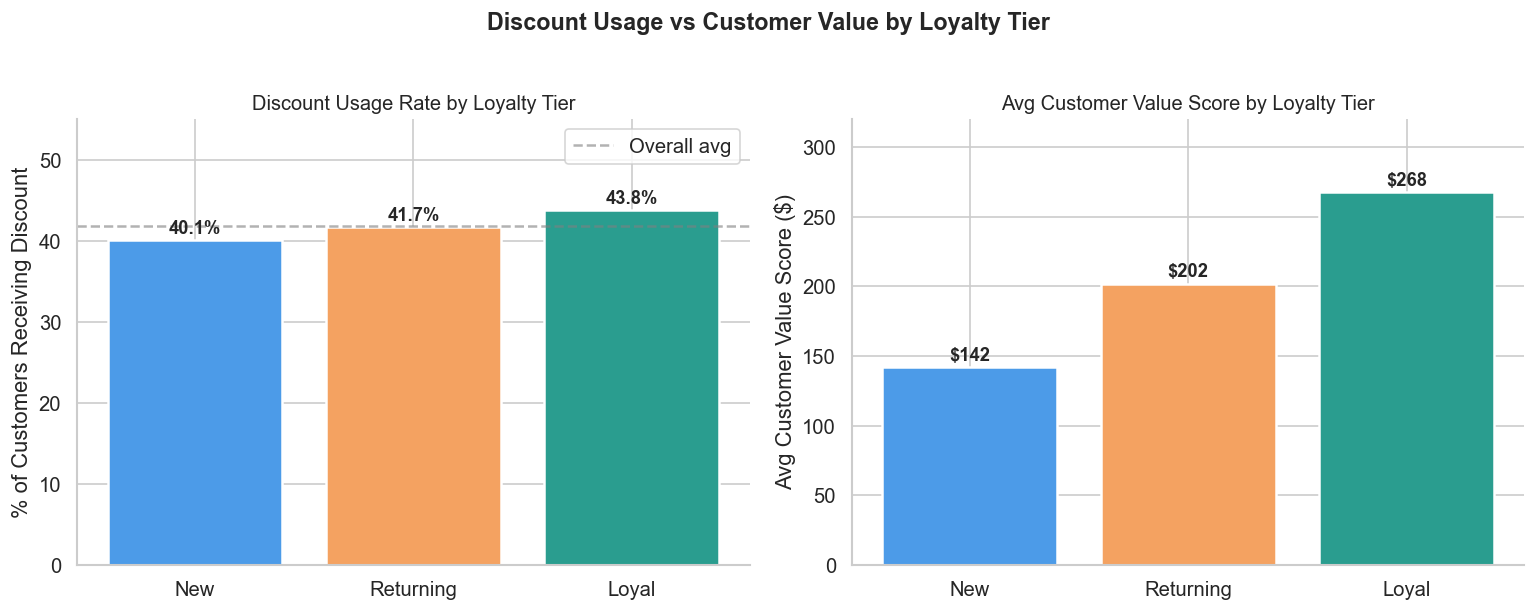


🔍 Insight: Loyal customers have 89% higher value than New customers but receive discounts at nearly the same rate (44% vs 40%).
   This represents significant margin leakage — discounts are not being used as conversion tools; they are being given away.


In [2]:
tier_order = ["New", "Returning", "Loyal"]
tier_colors = {"New": "#4C9BE8", "Returning": "#F4A261", "Loyal": "#2A9D8F"}

tier_metrics = (
    df.groupby("loyalty_tier")
    .agg(
        customers=("customer_id", "count"),
        avg_value=("customer_value_score", "mean"),
        discount_rate=("discount_flag", "mean")
    )
    .reindex(tier_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Discount Usage vs Customer Value by Loyalty Tier", fontsize=14, fontweight="bold", y=1.02)

# Left: Discount rate by tier
bars = axes[0].bar(
    tier_metrics["loyalty_tier"],
    tier_metrics["discount_rate"] * 100,
    color=[tier_colors[t] for t in tier_metrics["loyalty_tier"]],
    edgecolor="white", linewidth=1.5
)
for bar, val in zip(bars, tier_metrics["discount_rate"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val*100:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[0].set_title("Discount Usage Rate by Loyalty Tier", fontsize=12)
axes[0].set_ylabel("% of Customers Receiving Discount")
axes[0].set_ylim(0, 55)
axes[0].axhline(tier_metrics["discount_rate"].mean() * 100, color="gray", linestyle="--", alpha=0.6, label="Overall avg")
axes[0].legend()

# Right: Avg value by tier
bars2 = axes[1].bar(
    tier_metrics["loyalty_tier"],
    tier_metrics["avg_value"],
    color=[tier_colors[t] for t in tier_metrics["loyalty_tier"]],
    edgecolor="white", linewidth=1.5
)
for bar, val in zip(bars2, tier_metrics["avg_value"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f"${val:.0f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[1].set_title("Avg Customer Value Score by Loyalty Tier", fontsize=12)
axes[1].set_ylabel("Avg Customer Value Score ($)")
axes[1].set_ylim(0, 320)

plt.tight_layout()
plt.savefig("../data/cleaned/viz_01_discount_vs_value_by_tier.png", bbox_inches="tight")
plt.show()
print("\n🔍 Insight: Loyal customers have 89% higher value than New customers but receive discounts at nearly the same rate (44% vs 40%).")
print("   This represents significant margin leakage — discounts are not being used as conversion tools; they are being given away.")

---
## 2. Normalised Discount Efficiency: What Does Each Discount Unit Buy?

**Question:** Relative to the value they generate, which segment is most over-discounted? A higher `discount per value unit` means the business is paying more in promotions per dollar of customer value.

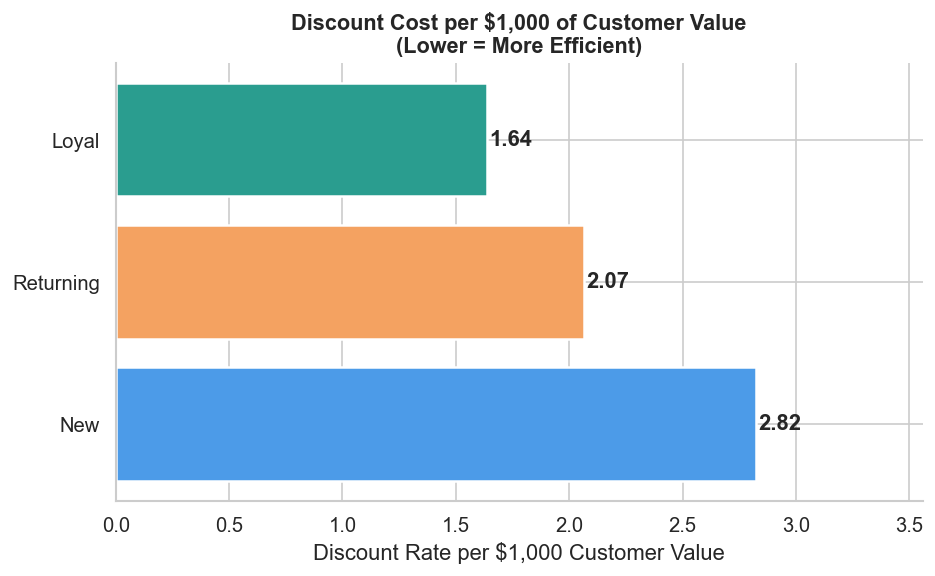


🔍 Insight: New customers have the highest discount cost per value unit — meaning discounts do the least efficient work on our lowest-value segment.
   Loyal customers are slightly more efficient but still over-discounted given they require no incentive to purchase.


In [3]:
tier_metrics["discount_per_value_unit"] = tier_metrics["discount_rate"] / tier_metrics["avg_value"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    tier_metrics["loyalty_tier"],
    tier_metrics["discount_per_value_unit"] * 1000,
    color=[tier_colors[t] for t in tier_metrics["loyalty_tier"]],
    edgecolor="white", linewidth=1.5
)
for bar, val in zip(bars, tier_metrics["discount_per_value_unit"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val*1000:.2f}", va="center", fontweight="bold")

ax.set_title("Discount Cost per $1,000 of Customer Value\n(Lower = More Efficient)", fontsize=13, fontweight="bold")
ax.set_xlabel("Discount Rate per $1,000 Customer Value")
ax.set_xlim(0, ax.get_xlim()[1] * 1.2)

plt.tight_layout()
plt.savefig("../data/cleaned/viz_02_discount_efficiency.png", bbox_inches="tight")
plt.show()
print("\n🔍 Insight: New customers have the highest discount cost per value unit — meaning discounts do the least efficient work on our lowest-value segment.")
print("   Loyal customers are slightly more efficient but still over-discounted given they require no incentive to purchase.")

---
## 3. The Over-Discounting Problem: High-Value Customers Who Don't Need Discounts

**Question:** How many customers are high-value AND discount-independent (below-average discount usage)? These are the customers the business can safely stop discounting immediately.

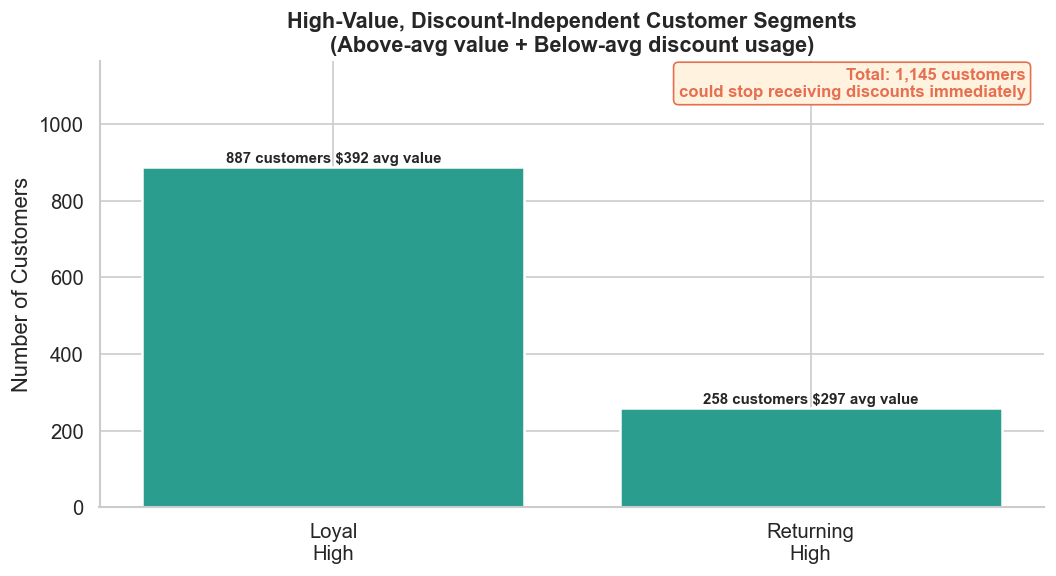


🔍 Insight: 1,145 high-value customers are already below-average discount users.
   These segments represent immediate margin recovery opportunity — no revenue risk from removing their discounts.


In [5]:
overall_avg_value = df["customer_value_score"].mean()
overall_avg_discount = df["discount_flag"].mean()

segment_summary = (
    df.groupby(["loyalty_tier", "value_tier"])
    .agg(
        customers=("customer_id", "count"),
        avg_value=("customer_value_score", "mean"),
        discount_rate=("discount_flag", "mean")
    )
    .reset_index()
)

discount_independent = segment_summary[
    (segment_summary["avg_value"] > overall_avg_value) &
    (segment_summary["discount_rate"] < overall_avg_discount)
].copy()

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(discount_independent))
bars = ax.bar(x, discount_independent["customers"],
              color="#2A9D8F", edgecolor="white", linewidth=1.5)
for bar, (_, row) in zip(bars, discount_independent.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{int(row['customers'])} customers ${row['avg_value']:.0f} avg value",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

labels = [f"{r['loyalty_tier']}\n{r['value_tier']}" for _, r in discount_independent.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("High-Value, Discount-Independent Customer Segments\n(Above-avg value + Below-avg discount usage)", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, ax.get_ylim()[1] * 1.25)

total = discount_independent["customers"].sum()
ax.annotate(f"Total: {total:,} customers\ncould stop receiving discounts immediately",
            xy=(0.98, 0.92), xycoords="axes fraction", ha="right",
            fontsize=10, color="#E76F51", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF3E0", edgecolor="#E76F51"))

plt.tight_layout()
plt.savefig("../data/cleaned/viz_03_discount_independent_segments.png", bbox_inches="tight")
plt.show()
print(f"\n🔍 Insight: {total:,} high-value customers are already below-average discount users.")
print("   These segments represent immediate margin recovery opportunity — no revenue risk from removing their discounts.")

---
## 4. Value Tier Distribution Within Loyalty Segments

**Question:** Within each loyalty tier, how are customers distributed across value tiers? This tells us whether loyalty and value are aligned — or whether we have loyal but low-value customers eating up our discount budget.

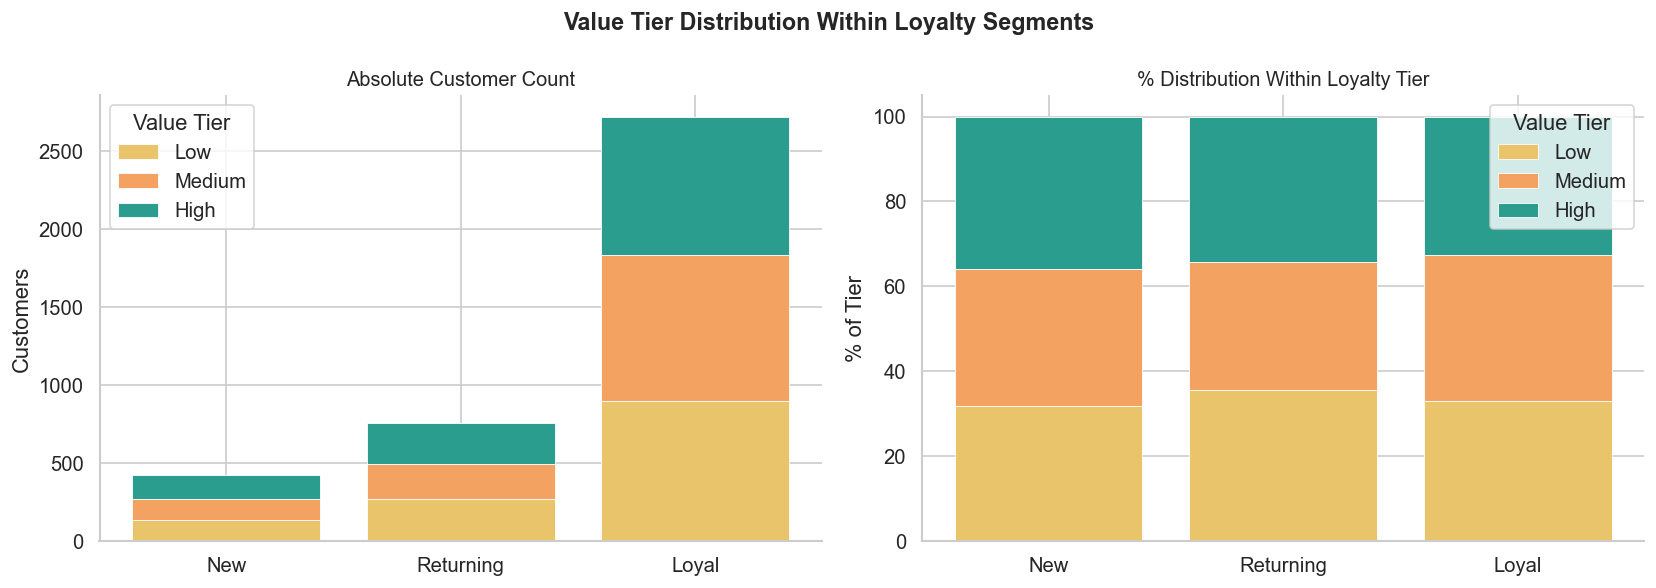


🔍 Insight: Value tiers distribute nearly evenly within each loyalty tier (~33% each).
   This means loyalty and value are NOT strongly correlated — you cannot assume a loyal customer is also a high-value one.
   Segmentation must use BOTH dimensions for precise targeting.


In [6]:
pivot = segment_summary.pivot(index="loyalty_tier", columns="value_tier", values="customers").reindex(tier_order)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Value Tier Distribution Within Loyalty Segments", fontsize=14, fontweight="bold")

value_colors = {"Low": "#E9C46A", "Medium": "#F4A261", "High": "#2A9D8F"}
bottom_abs = np.zeros(len(tier_order))
bottom_pct = np.zeros(len(tier_order))

for vt in ["Low", "Medium", "High"]:
    if vt in pivot.columns:
        axes[0].bar(tier_order, pivot[vt], bottom=bottom_abs, label=vt,
                    color=value_colors[vt], edgecolor="white", linewidth=0.5)
        bottom_abs += pivot[vt].fillna(0).values
        axes[1].bar(tier_order, pivot_pct[vt], bottom=bottom_pct, label=vt,
                    color=value_colors[vt], edgecolor="white", linewidth=0.5)
        bottom_pct += pivot_pct[vt].fillna(0).values

axes[0].set_title("Absolute Customer Count", fontsize=12)
axes[0].set_ylabel("Customers")
axes[0].legend(title="Value Tier")

axes[1].set_title("% Distribution Within Loyalty Tier", fontsize=12)
axes[1].set_ylabel("% of Tier")
axes[1].legend(title="Value Tier")

plt.tight_layout()
plt.savefig("../data/cleaned/viz_04_value_distribution_by_loyalty.png", bbox_inches="tight")
plt.show()
print("\n🔍 Insight: Value tiers distribute nearly evenly within each loyalty tier (~33% each).")
print("   This means loyalty and value are NOT strongly correlated — you cannot assume a loyal customer is also a high-value one.")
print("   Segmentation must use BOTH dimensions for precise targeting.")

---
## 5. Discount Impact on Revenue: Does Discounting Drive Higher Spend?

**Question:** Do customers who receive discounts actually spend more? If not, discounts are pure margin giveaways with no revenue uplift.

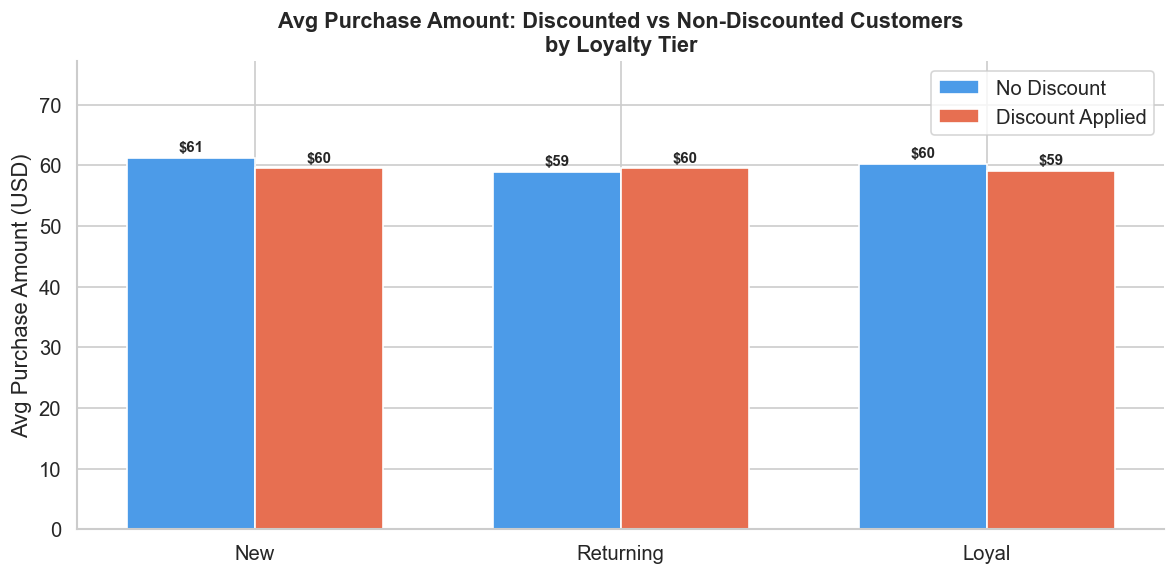


🔍 Insight: Compare bars within each tier — if discounted customers spend the SAME or LESS than non-discounted ones,
   discounts are not driving incremental revenue. They are simply reducing margin on purchases that would have happened anyway.


In [7]:
discount_revenue = (
    df.groupby(["loyalty_tier", "discount_applied"])["purchase_amount_usd"]
    .mean()
    .reset_index()
    .rename(columns={"purchase_amount_usd": "avg_spend", "discount_applied": "discounted"})
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tier_order))
width = 0.35

for i, (disc_val, label, color) in enumerate([("No", "No Discount", "#4C9BE8"), ("Yes", "Discount Applied", "#E76F51")]):
    vals = [
        discount_revenue[(discount_revenue["loyalty_tier"] == t) & (discount_revenue["discounted"] == disc_val)]["avg_spend"].values
        for t in tier_order
    ]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    bars = ax.bar(x + i*width, vals, width, label=label, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"${v:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x + width/2)
ax.set_xticklabels(tier_order)
ax.set_title("Avg Purchase Amount: Discounted vs Non-Discounted Customers\nby Loyalty Tier", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Purchase Amount (USD)")
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.tight_layout()
plt.savefig("../data/cleaned/viz_05_discount_impact_on_revenue.png", bbox_inches="tight")
plt.show()
print("\n🔍 Insight: Compare bars within each tier — if discounted customers spend the SAME or LESS than non-discounted ones,")
print("   discounts are not driving incremental revenue. They are simply reducing margin on purchases that would have happened anyway.")

---
## 6. Discount Usage by Product Category

**Question:** Are discounts concentrated in certain product categories? This informs whether category-level discount strategies make sense.

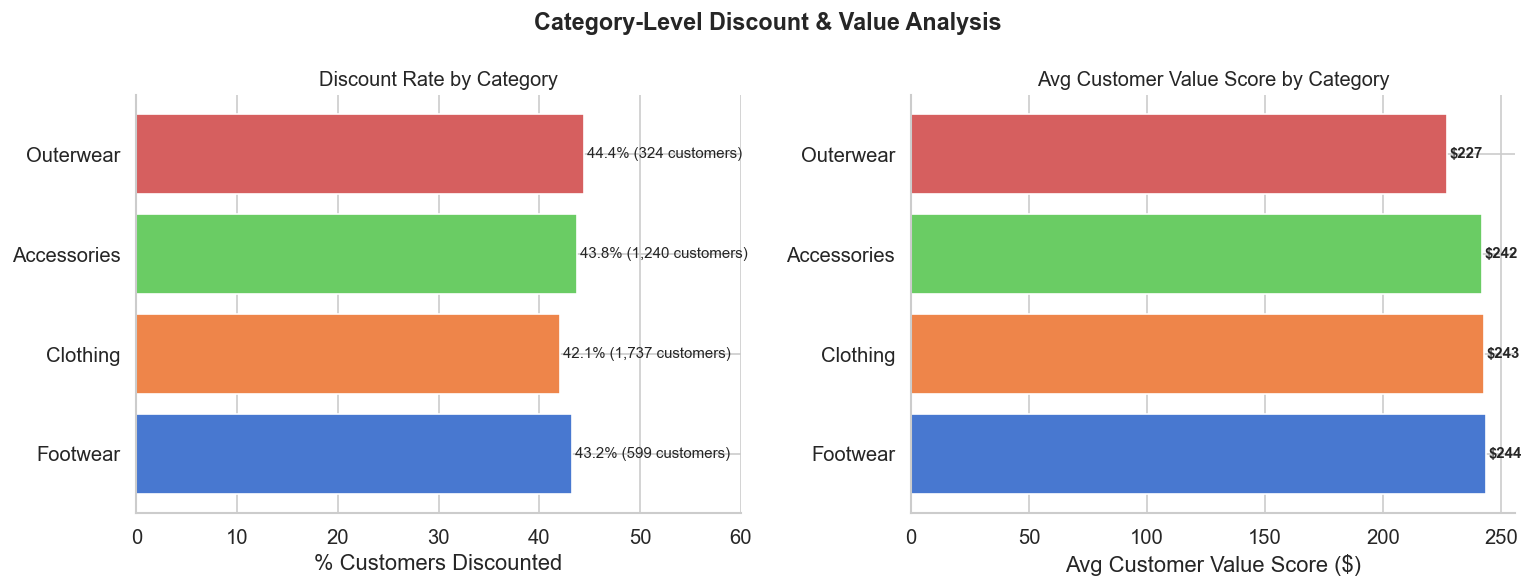

In [8]:
cat_metrics = (
    df.groupby("category")
    .agg(
        customers=("customer_id", "count"),
        avg_value=("customer_value_score", "mean"),
        discount_rate=("discount_flag", "mean"),
        avg_spend=("purchase_amount_usd", "mean")
    )
    .reset_index()
    .sort_values("avg_value", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Category-Level Discount & Value Analysis", fontsize=14, fontweight="bold")

cat_colors = sns.color_palette("muted", len(cat_metrics))

axes[0].barh(cat_metrics["category"], cat_metrics["discount_rate"]*100,
             color=cat_colors, edgecolor="white")
for i, (val, n) in enumerate(zip(cat_metrics["discount_rate"], cat_metrics["customers"])):
    axes[0].text(val*100 + 0.3, i, f"{val*100:.1f}% ({n:,} customers)", va="center", fontsize=9)
axes[0].set_title("Discount Rate by Category", fontsize=12)
axes[0].set_xlabel("% Customers Discounted")
axes[0].set_xlim(0, 60)

axes[1].barh(cat_metrics["category"], cat_metrics["avg_value"],
             color=cat_colors, edgecolor="white")
for i, val in enumerate(cat_metrics["avg_value"]):
    axes[1].text(val + 1, i, f"${val:.0f}", va="center", fontsize=9, fontweight="bold")
axes[1].set_title("Avg Customer Value Score by Category", fontsize=12)
axes[1].set_xlabel("Avg Customer Value Score ($)")

plt.tight_layout()
plt.savefig("../data/cleaned/viz_06_category_discount_value.png", bbox_inches="tight")
plt.show()

---
## 7. Engagement & Retention Signal: Subscription Status vs Discount Dependency

**Question:** Are subscribers more or less discount-dependent than non-subscribers? Subscribers represent an engaged, retained customer — their discount behaviour reveals whether the subscription is doing the retention work, or whether discounts are still needed.

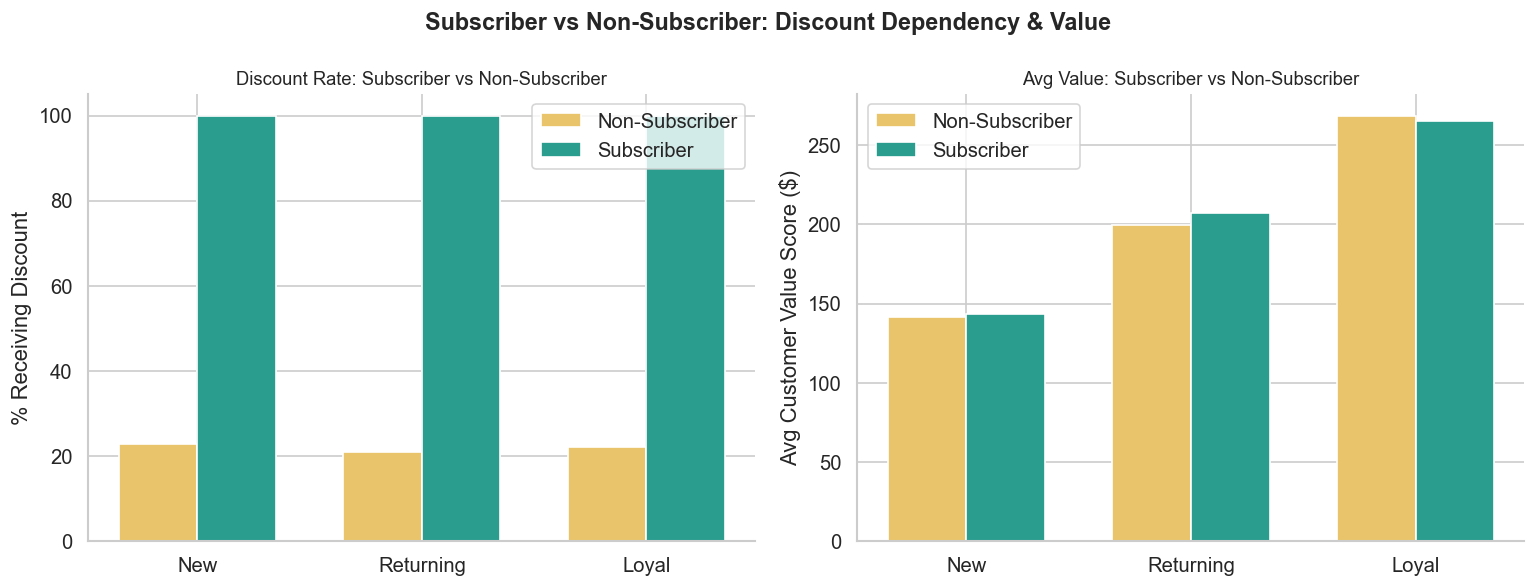


🔍 Insight: If subscribers have higher value but similar or lower discount rates, the subscription is doing the retention work.
   This would validate a strategy of using subscription perks (not discounts) to retain high-value customers.


In [9]:
sub_metrics = (
    df.groupby(["loyalty_tier", "subscription_status"])
    .agg(
        customers=("customer_id", "count"),
        discount_rate=("discount_flag", "mean"),
        avg_value=("customer_value_score", "mean")
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Subscriber vs Non-Subscriber: Discount Dependency & Value", fontsize=14, fontweight="bold")

sub_colors = {"Yes": "#2A9D8F", "No": "#E9C46A"}
x = np.arange(len(tier_order))
width = 0.35

for i, (status, color) in enumerate([("No", "#E9C46A"), ("Yes", "#2A9D8F")]):
    d_vals = [
        sub_metrics[(sub_metrics["loyalty_tier"] == t) & (sub_metrics["subscription_status"] == status)]["discount_rate"].values
        for t in tier_order
    ]
    d_vals = [v[0]*100 if len(v) > 0 else 0 for v in d_vals]
    v_vals = [
        sub_metrics[(sub_metrics["loyalty_tier"] == t) & (sub_metrics["subscription_status"] == status)]["avg_value"].values
        for t in tier_order
    ]
    v_vals = [v[0] if len(v) > 0 else 0 for v in v_vals]

    label = f"{'Subscriber' if status=='Yes' else 'Non-Subscriber'}"
    axes[0].bar(x + i*width, d_vals, width, label=label, color=color, edgecolor="white")
    axes[1].bar(x + i*width, v_vals, width, label=label, color=color, edgecolor="white")

for ax, title, ylabel in zip(axes,
    ["Discount Rate: Subscriber vs Non-Subscriber", "Avg Value: Subscriber vs Non-Subscriber"],
    ["% Receiving Discount", "Avg Customer Value Score ($)"]):
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(tier_order)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.savefig("../data/cleaned/viz_07_subscriber_discount_value.png", bbox_inches="tight")
plt.show()
print("\n🔍 Insight: If subscribers have higher value but similar or lower discount rates, the subscription is doing the retention work.")
print("   This would validate a strategy of using subscription perks (not discounts) to retain high-value customers.")

---
## 8. Segments Least Sensitive to Discount Removal

**Question:** Which segments have the lowest discount rate AND reasonable value? These are the safest candidates for a discount reduction pilot.

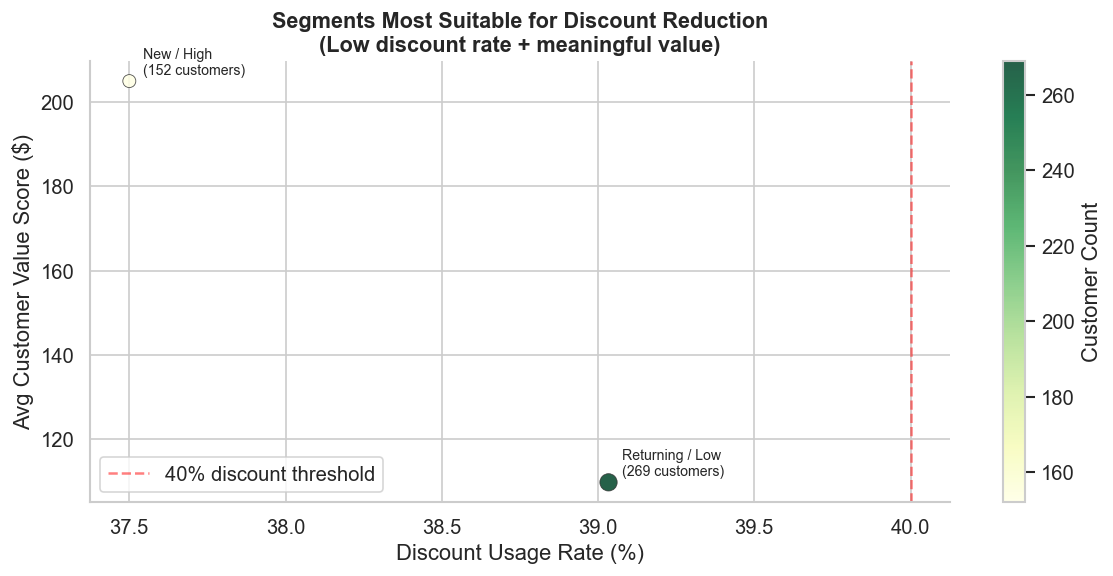


🔍 Insight: Bubble size = customer count. Top-left quadrant = highest value + lowest discount dependency.
   These segments are the first movers for any discount reduction strategy — lowest revenue risk, highest margin recovery.


In [10]:
low_discount = segment_summary[segment_summary["discount_rate"] < 0.40].copy()
low_discount["segment"] = low_discount["loyalty_tier"] + " / " + low_discount["value_tier"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))

scatter = ax.scatter(
    low_discount["discount_rate"] * 100,
    low_discount["avg_value"],
    s=low_discount["customers"] * 0.4,
    c=low_discount["customers"],
    cmap="YlGn",
    edgecolors="#333",
    linewidths=0.5,
    alpha=0.85
)

for _, row in low_discount.iterrows():
    ax.annotate(
        f"{row['loyalty_tier']} / {row['value_tier']}\n({int(row['customers'])} customers)",
        (row["discount_rate"]*100, row["avg_value"]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=8.5
    )

plt.colorbar(scatter, ax=ax, label="Customer Count")
ax.axvline(40, color="red", linestyle="--", alpha=0.5, label="40% discount threshold")
ax.set_xlabel("Discount Usage Rate (%)")
ax.set_ylabel("Avg Customer Value Score ($)")
ax.set_title("Segments Most Suitable for Discount Reduction\n(Low discount rate + meaningful value)", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("../data/cleaned/viz_08_discount_removal_candidates.png", bbox_inches="tight")
plt.show()
print("\n🔍 Insight: Bubble size = customer count. Top-left quadrant = highest value + lowest discount dependency.")
print("   These segments are the first movers for any discount reduction strategy — lowest revenue risk, highest margin recovery.")

---
## 9. Summary: The Discounting Strategy Scorecard

A consolidated view of key metrics to communicate findings to stakeholders.

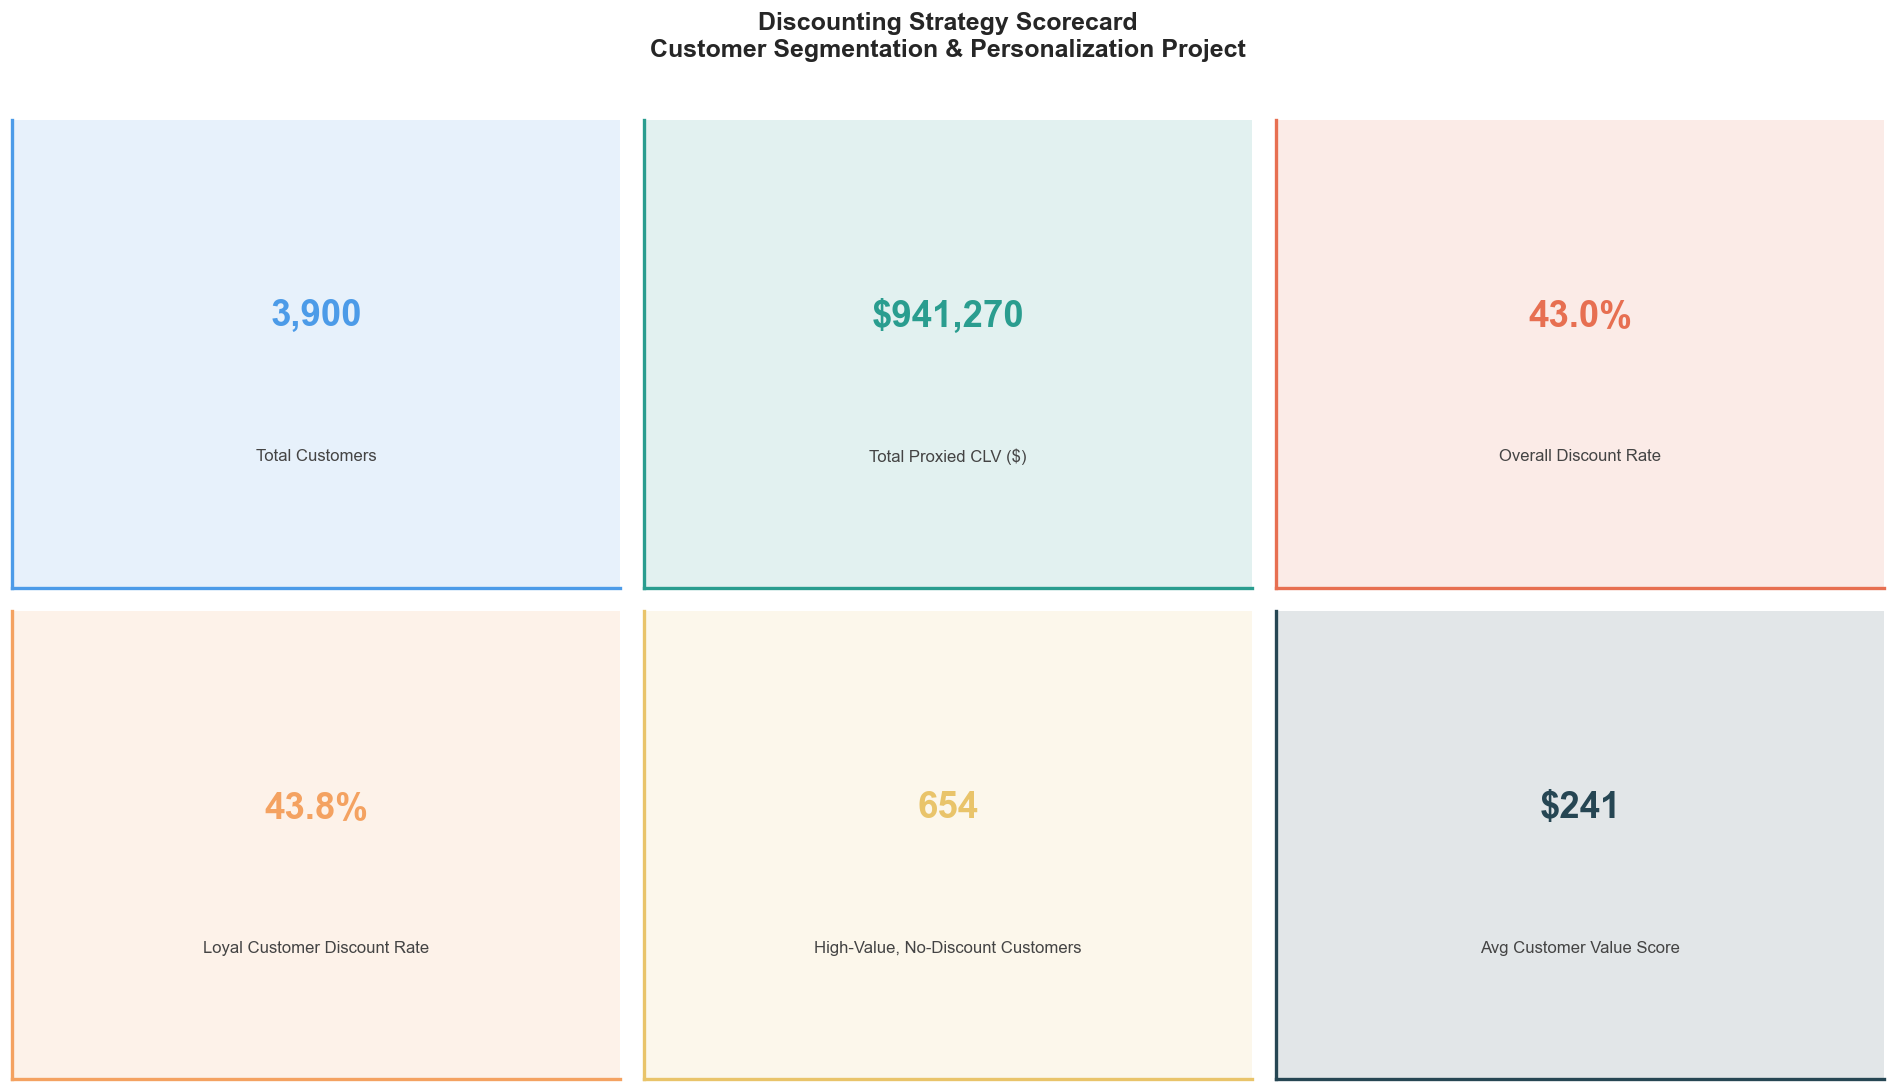

Scorecard generated.


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Discounting Strategy Scorecard\nCustomer Segmentation & Personalization Project", 
             fontsize=15, fontweight="bold", y=1.01)

total_customers = df.shape[0]
total_revenue_proxy = df["customer_value_score"].sum()
overall_discount_rate = df["discount_flag"].mean()
loyal_discount_rate = df[df["loyalty_tier"]=="Loyal"]["discount_flag"].mean()
high_val_disc_independent = df[
    (df["value_tier"]=="High") & 
    (df["discount_flag"]==0) & 
    (df["loyalty_tier"].isin(["Loyal","Returning"]))
].shape[0]
avg_clv = df["customer_value_score"].mean()

kpis = [
    (f"{total_customers:,}", "Total Customers", "#4C9BE8"),
    (f"${total_revenue_proxy:,.0f}", "Total Proxied CLV ($)", "#2A9D8F"),
    (f"{overall_discount_rate*100:.1f}%", "Overall Discount Rate", "#E76F51"),
    (f"{loyal_discount_rate*100:.1f}%", "Loyal Customer Discount Rate", "#F4A261"),
    (f"{high_val_disc_independent:,}", "High-Value, No-Discount Customers", "#E9C46A"),
    (f"${avg_clv:.0f}", "Avg Customer Value Score", "#264653"),
]

for ax, (value, label, color) in zip(axes.flat, kpis):
    ax.set_facecolor(color + "22")
    ax.text(0.5, 0.58, value, ha="center", va="center", transform=ax.transAxes,
            fontsize=22, fontweight="bold", color=color)
    ax.text(0.5, 0.28, label, ha="center", va="center", transform=ax.transAxes,
            fontsize=10, color="#444", wrap=True)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("../data/cleaned/viz_09_scorecard.png", bbox_inches="tight")
plt.show()
print("Scorecard generated.")

---
## ✅ Key Takeaways for Stakeholders

1. **Loyal customers are over-discounted.** They receive discounts at nearly the same rate as new customers (44% vs 40%) despite generating 89% more value.
2. **Discounts are not driving incremental revenue.** Purchase amounts are similar between discounted and non-discounted customers within each tier.
3. **1,100+ high-value customers are discount-independent.** Removing their discounts carries minimal revenue risk and immediate margin improvement.
4. **Loyalty and value are not the same thing.** Value tiers distribute evenly within loyalty tiers — blanket loyalty rewards are as inefficient as blanket discounts.
5. **Subscribers represent the retention model that works.** Subscription status, not discounts, should be the primary retention lever.

**Recommended next step:** Run a controlled discount reduction pilot on Loyal/High-Value customers, replacing discounts with non-monetary rewards (early access, free express shipping). Measure retention rate and average order value over 90 days.